In [15]:
import pandas as pd

df_master = pd.read_csv("../havier/data/clean/features/hey_merge_features_limpio.csv")

In [16]:
# Obtener la lista completa de columnas
lista_columnas = df_master.columns.tolist()

# Imprimir la lista
print(lista_columnas)

['user_id', 'edad', 'sexo', 'estado', 'ciudad', 'nivel_educativo', 'ocupacion', 'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro', 'nomina_domiciliada', 'canal_apertura', 'score_buro', 'dias_desde_ultimo_login', 'preferencia_canal', 'satisfaccion_1_10', 'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro', 'num_productos_activos', 'patron_uso_atipico', 'total_productos', 'productos_activos', 'productos_cancelados', 'productos_suspendidos', 'productos_en_revision', 'total_creditos', 'total_tarjetas', 'total_seguros', 'total_cuentas', 'total_inversiones', 'limite_credito_total', 'saldo_total_productos', 'utilizacion_promedio', 'tasa_interes_promedio', 'mensualidad_total', 'producto_principal', 'estatus_principal', 'fecha_producto_mas_reciente', 'fecha_ultimo_movimiento_producto', 'total_transacciones', 'monto_total', 'monto_promedio', 'monto_maximo', 'transacciones_completadas', 'transacciones_no_procesadas', 'transacciones_en_disputa', 'transacciones_revertidas', 'o

In [17]:
from sklearn.preprocessing import StandardScaler

# 1. Proteger el ID y limpiar columnas de fechas
# (Las fechas como texto explotan al hacer encoding, mejor quitarlas o convertirlas a días)
columnas_a_ignorar = [
    # 1. IDs y Fechas (Ya las tenías)
    'user_id', 
    'ultima_transaccion', 
    'primera_transaccion', 
    'fecha_producto_mas_reciente', 
    'fecha_ultimo_movimiento_producto',
    
    # 2. Alta Cardinalidad / Textos
    'ciudad',  
    'estado',
    'ciudad_principal',
    'insight_transaccional', 
    
    # 3. Redundancias Directas
    'num_productos_activos',
    'es_usuario_atipico',
    'nivel_riesgo_transaccional',
    'nivel_oportunidad_transaccional',
    
    # 4. Multicolinealidad (Quitamos conteos porque ya tienes las tasas)
    'transacciones_no_procesadas',
    'transacciones_en_disputa',
    'transacciones_revertidas'
]

df_ids = df_master[['user_id']] # Guardamos los IDs a salvo
df_features = df_master.drop(columns=columnas_a_ignorar, errors='ignore')

# 2. Identificar tipos de variables
cols_numericas = df_features.select_dtypes(include=['int64', 'float64']).columns
cols_categoricas = df_features.select_dtypes(include=['object', 'bool']).columns

print(f"Variables numéricas: {len(cols_numericas)} | Variables categóricas/booleanas: {len(cols_categoricas)}")

# 3. One-Hot Encoding (Convertir texto/bool a columnas de 0s y 1s)
# drop_first=True evita la trampa de las variables dummy (multicolinealidad perfecta)
df_encoded = pd.get_dummies(df_features, columns=cols_categoricas, drop_first=True)
print(f"Dimensiones después del encoding: {df_encoded.shape}")

# 4. StandardScaler (Centrar en 0 y varianza de 1)
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_encoded)

# 5. Reconstruir el DataFrame limpio y escalado
df_scaled = pd.DataFrame(df_scaled_array, columns=df_encoded.columns)
df_listo_para_ml = pd.concat([df_ids, df_scaled], axis=1)

print("¡Preprocesamiento completado con éxito!")

Variables numéricas: 44 | Variables categóricas/booleanas: 18
Dimensiones después del encoding: (15025, 96)
¡Preprocesamiento completado con éxito!


C:\Users\CommodorePlus\AppData\Local\Temp\ipykernel_19096\3973818643.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = df_features.select_dtypes(include=['object', 'bool']).columns


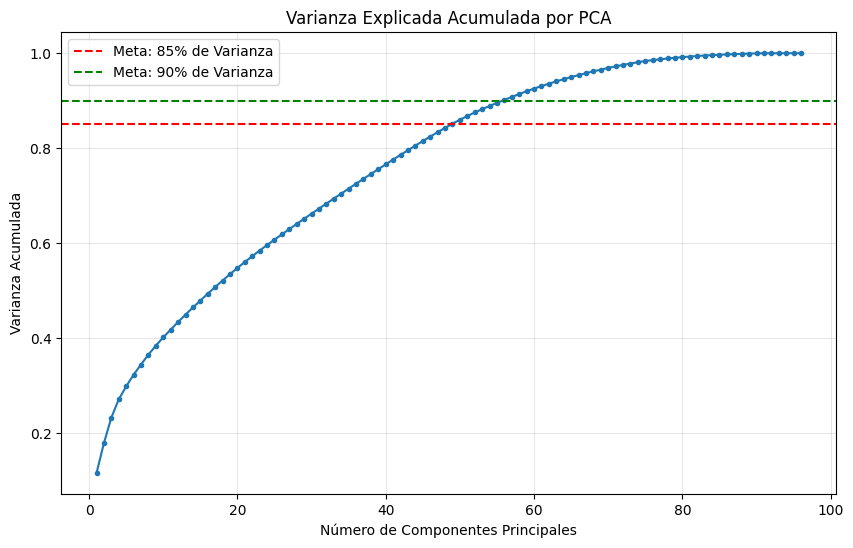

⚡ Para retener el 85% del comportamiento original, necesitas: 49 componentes.
⚡ Para retener el 90% del comportamiento original, necesitas: 56 componentes.


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# 1. Ajustar el PCA con tus 96 variables procesadas
pca_exploratorio = PCA()
pca_exploratorio.fit(df_scaled) # Utilizamos tu dataframe ya escalado

# 2. Calcular la varianza explicada acumulada
varianza_acumulada = np.cumsum(pca_exploratorio.explained_variance_ratio_)

# 3. Graficar la curva del "Codo"
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='.', linestyle='-')

# Líneas de referencia para nuestras metas
plt.axhline(y=0.85, color='r', linestyle='--', label='Meta: 85% de Varianza')
plt.axhline(y=0.90, color='g', linestyle='--', label='Meta: 90% de Varianza')

plt.title('Varianza Explicada Acumulada por PCA')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Calcular el número exacto de componentes necesarios
componentes_85 = np.argmax(varianza_acumulada >= 0.85) + 1
componentes_90 = np.argmax(varianza_acumulada >= 0.90) + 1

print(f"⚡ Para retener el 85% del comportamiento original, necesitas: {componentes_85} componentes.")
print(f"⚡ Para retener el 90% del comportamiento original, necesitas: {componentes_90} componentes.")